# **Wolf Sheep Predation** — Comparing Two BehaviorSpace Runs

Comparing **100 sheep / 100 wolves** vs **400 sheep / 400 wolves** — same model code (unmodified), same parameter grid (`sheep-reproduce`, `wolf-reproduce`, `grass-regrowth-time`), same time limit (1500 ticks).




## Data links:

In [1]:
bs100link='https://github.com/DACSS-CSSmeths-summer/abm/raw/main/experiments/experiment_100_100.csv'
bs400link='https://github.com/DACSS-CSSmeths-summer/abm/raw/main/experiments/experiment_400_400.csv'

> **`You will bring another file, and compare it to ONE of these`**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## 1.- Load the data

BehaviorSpace table exports start with 6 lines of metadata (model name, timestamp, world dimensions) before the actual header row, so we skip them with `skiprows=6`. We also rename the columns to something easier to work with in code — the raw column names come out as things like `[run number]` and `sheep-reproduce`, which are awkward to reference in pandas.

In [3]:
def read_bs_table(path):
    df = pd.read_csv(path, skiprows=6)
    df.columns = ["run_number", "sheep_reproduce", "wolf_reproduce",
                  "grass_regrowth_time", "step",
                  "land_with_grass", "count_sheep", "count_wolves"]
    return df

exp_100 = read_bs_table(bs100link)
exp_400 = read_bs_table(bs400link)

Take a look:

In [4]:
exp_100.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   run_number           1215 non-null   int64  
 1   sheep_reproduce      1215 non-null   int64  
 2   wolf_reproduce       1215 non-null   int64  
 3   grass_regrowth_time  1215 non-null   int64  
 4   step                 1215 non-null   int64  
 5   land_with_grass      1215 non-null   float64
 6   count_sheep          1215 non-null   int64  
 7   count_wolves         1215 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 76.1 KB


In [5]:
exp_400.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   run_number           1215 non-null   int64  
 1   sheep_reproduce      1215 non-null   int64  
 2   wolf_reproduce       1215 non-null   int64  
 3   grass_regrowth_time  1215 non-null   int64  
 4   step                 1215 non-null   int64  
 5   land_with_grass      1215 non-null   float64
 6   count_sheep          1215 non-null   int64  
 7   count_wolves         1215 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 76.1 KB


> `one of these will be your own file`

## 2.- Derived variables

None of these are in the raw BehaviorSpace output — we compute them from `count_sheep`, `count_wolves`, and `step`:

- **`censored`**: the run hit the time limit (1500 ticks) without resolving. We don't actually know what would have happened afterward — only that the ecosystem survived at least that long.
- **`wolves_survived`**: at least one wolf was still alive when the run ended.
- **`total_collapse`**: both sheep and wolves were gone by the end (the ecosystem fully collapsed).

In [6]:
def add_derived(df, time_limit=1500):
    df = df.copy()
    df["censored"] = df["step"] == time_limit
    df["sheep_survived"] = df["count_sheep"] > 0
    df["wolves_survived"] = df["count_wolves"] > 0
    df["total_collapse"] = (~df["sheep_survived"]) & (~df["wolves_survived"])
    return df

exp_100 = add_derived(exp_100)
exp_400 = add_derived(exp_400)

exp_100["config"] = "100Sheep_100Wolves"
exp_400["config"] = "400Sheep_400Wolves"

both = pd.concat([exp_100, exp_400], ignore_index=True)
both.head()

,run_number,sheep_reproduce,wolf_reproduce,grass_regrowth_time,step,land_with_grass,count_sheep,count_wolves,censored,sheep_survived,wolves_survived,total_collapse,config
0,4,4,4,175,1500,44.367551,22,0,True,True,False,False,100Sheep_100Wolves
1,5,4,4,175,1500,59.630911,22,0,True,True,False,False,100Sheep_100Wolves
2,6,4,4,175,1500,69.511726,49,0,True,True,False,False,100Sheep_100Wolves
3,3,4,4,150,1500,53.364091,22,0,True,True,False,False,100Sheep_100Wolves
4,7,4,4,200,1500,36.447520,10,0,True,True,False,False,100Sheep_100Wolves


## 3.- Descriptive summary

For each configuration, we summarize the wolf→sheep→grass dependency chain into four numbers: what fraction of runs ended in total collapse, what fraction still had sheep alive (the sheep→grass link holding), what fraction still had wolves alive (the wolf→sheep link holding), and what fraction were censored (hit the time limit before resolving).

In [7]:
summary_table = both.groupby("config")[["total_collapse", "sheep_survived", "wolves_survived", "censored"]].mean()
summary_table

,total_collapse,sheep_survived,wolves_survived,censored
config,,,,
100Sheep_100Wolves,0.750617,0.249383,0.0,0.249383
400Sheep_400Wolves,0.953909,0.046091,0.0,0.046091



**ANALYSIS 1:**  `wolves_survived` sitting at 0.0 in *both* configurations tells you the wolf→sheep dependency breaks down regardless of scale — wolves aren't managing to rely on the sheep population for survival, no matter how many of either there are. `sheep_survived` staying above zero in both, meanwhile, shows the sheep→grass dependency is more resilient. Don't just glance at either row on its own — the comparison is between rows, and between the two dependency links in the chain.

> **`You will update this analysis when you compare your results.`**

## 4.- Heatmap — probability of total collapse, by parameters

Each cell shows the proportion of runs (averaged over the 3 repetitions) that ended in total collapse, for a given combination of `sheep-reproduce` and `wolf-reproduce`.

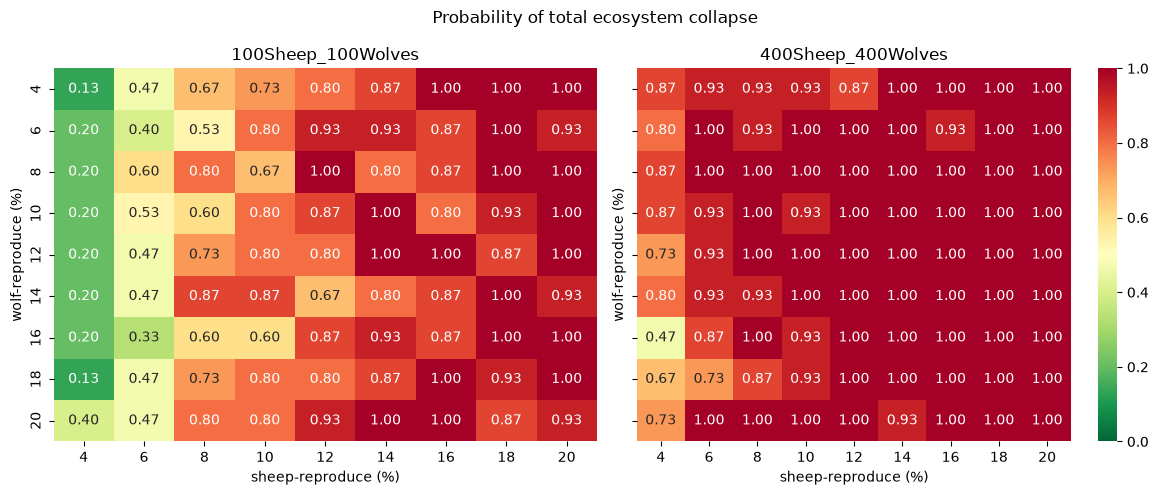

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (config_name, sub) in zip(axes, both.groupby("config")):
    pivot = sub.pivot_table(index="wolf_reproduce", columns="sheep_reproduce",
                             values="total_collapse", aggfunc="mean")
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn_r", vmin=0, vmax=1,
                annot=True, fmt=".2f", cbar=(ax is axes[-1]))
    ax.set_title(config_name)
    ax.set_xlabel("sheep-reproduce (%)")
    ax.set_ylabel("wolf-reproduce (%)")

plt.suptitle("Probability of total ecosystem collapse")
plt.tight_layout()
plt.show()

**ANALYSIS 2:** in the `100Sheep_100Wolves` panel, follow any row from left to right — the probability of collapse climbs steadily as `sheep-reproduce` increases, from as low as 0.13 in the bottom-left corner up to 1.00 by the time `sheep-reproduce` reaches 12–14. That's the sheep→grass link breaking down faster when sheep reproduce more aggressively (more grazing pressure than the grass can regenerate). Now follow a single *column* up and down (fixed `sheep-reproduce`, varying `wolf-reproduce`) — there's no comparable pattern; the values bounce around without climbing or falling in any consistent direction. That's the same "wolf-reproduce doesn't matter" result we found earlier, now visible directly in the picture instead of just in a coefficient table.

In the `400Sheep_400Wolves` panel, most of the grid is saturated at or near 1.00 regardless of either parameter — at this density, the ecosystem collapses almost no matter what you set `sheep-reproduce` or `wolf-reproduce` to. The one place a gradient survives is the leftmost column (`sheep-reproduce=4`), which still dips as low as 0.47 — a hint that even at high density, the sheep→grass link isn't *completely* overwhelmed at the lowest reproduction rate, just much closer to it than at 100/100.

> **`You will update this analysis when you compare your results.`**

## 5.- Kaplan-Meier survival curves and the log-rank test


### Installation:

In [9]:
### do you have it?
! pip show lifelines

Name: lifelines
Version: 0.30.3
Summary: Survival analysis in Python, including Kaplan Meier, Nelson Aalen and regression
Home-page: https://github.com/CamDavidsonPilon/lifelines
Author: Cameron Davidson-Pilon
Author-email: cam.davidson.pilon@gmail.com
License: MIT
Location: C:\Users\markg\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages
Requires: autograd, autograd-gamma, formulaic, matplotlib, numpy, pandas, scipy
Required-by: 


In [10]:
### IF NOT, then uncomment this line and run it
# !pip install lifelines --quiet


Why not just compare the average `step` between the two configurations and call it done? Because some runs never actually collapsed — they hit the 1500-tick time limit still going, which is exactly what `censored` flags back in section 2. We don't know when (or if) those runs would have collapsed; we only know they lasted *at least* that long.

If we handled that carelessly, we'd have two bad options: throw the censored runs out entirely (wasting real information — "survived at least 1500 ticks" still tells us something), or treat them as if they collapsed exactly at tick 1500 (which isn't true either, and would make long-lasting runs look worse than they actually were).

Kaplan-Meier is built exactly for this situation: it estimates the probability that the ecosystem is still going at each tick, using *every* run's information correctly — both the ones that collapsed and the ones still going when we stopped watching. Once we have that curve for each configuration, the log-rank test gives us a formal way to ask whether the two curves are actually different from each other, or whether the gap we see could just be random noise.

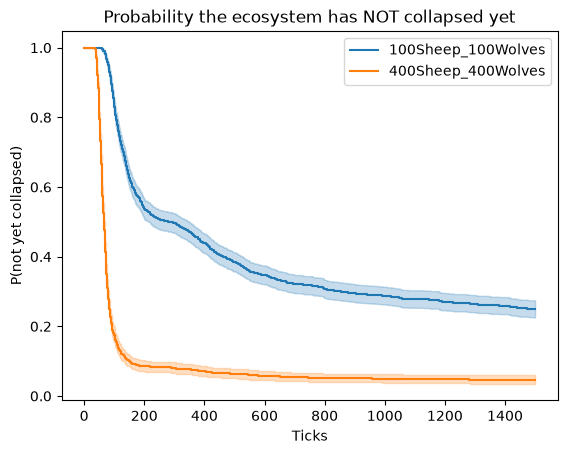

In [11]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

both["event"] = ~both["censored"]  # event = 1 if collapse actually happened before the time limit

sub_100 = both[both["config"] == "100Sheep_100Wolves"]
sub_400 = both[both["config"] == "400Sheep_400Wolves"]

kmf_100 = KaplanMeierFitter()
kmf_400 = KaplanMeierFitter()

ax = plt.subplot(111)
kmf_100.fit(sub_100["step"], event_observed=sub_100["event"], label="100Sheep_100Wolves")
kmf_100.plot_survival_function(ax=ax)

kmf_400.fit(sub_400["step"], event_observed=sub_400["event"], label="400Sheep_400Wolves")
kmf_400.plot_survival_function(ax=ax)

plt.title("Probability the ecosystem has NOT collapsed yet")
plt.xlabel("Ticks")
plt.ylabel("P(not yet collapsed)")
plt.show()

**ANALYSIS 3:** the two curves separate almost immediately and never come back together. By around tick 100, `400Sheep_400Wolves` (orange) has already dropped below 0.2, while `100Sheep_100Wolves` (blue) is still above 0.6. By the end (tick 1500), orange has flattened out near 0.05 — matching the ~4.6% sheep-survival rate we found earlier — while blue settles around 0.25–0.27, matching the ~25% we found back in the summary table. The shaded bands are confidence intervals; notice they widen the further right you go, especially for the blue curve, because fewer runs are still "at risk" (haven't collapsed yet) that far out, so there's more uncertainty about the true probability at that point.

> **`You will update this analysis when you compare your results.`**

In [12]:
results = logrank_test(sub_100["step"], sub_400["step"],
                        event_observed_A=sub_100["event"],
                        event_observed_B=sub_400["event"])
results.print_summary()

**ANALYSIS 4:** the test statistic (1084.50) is enormous for a chi-squared distribution with 1 degree of freedom — you'd only need a value above about 3.84 to call this significant at the conventional 0.05 threshold. The `p<0.005` shown is really just a display floor; the `-log2(p)` column (787.67) tells the real story — the actual p-value is on the order of 2⁻⁷⁸⁷, a number with no practical meaning as a probability anymore. It just means: as close to "impossible that this is due to chance" as the test can express.

In plain terms: the difference in how `100Sheep_100Wolves` and `400Sheep_400Wolves` arrive at collapse is not something run-to-run randomness could plausibly produce. Scaling the population up from 100 to 400 (same 1:1 ratio, same code, same parameter grid) genuinely changes how the ecosystem behaves over time — confirming, with a formal test, what the heatmap and the summary table already suggested.

> **`You will update this analysis when you compare your results.`**
